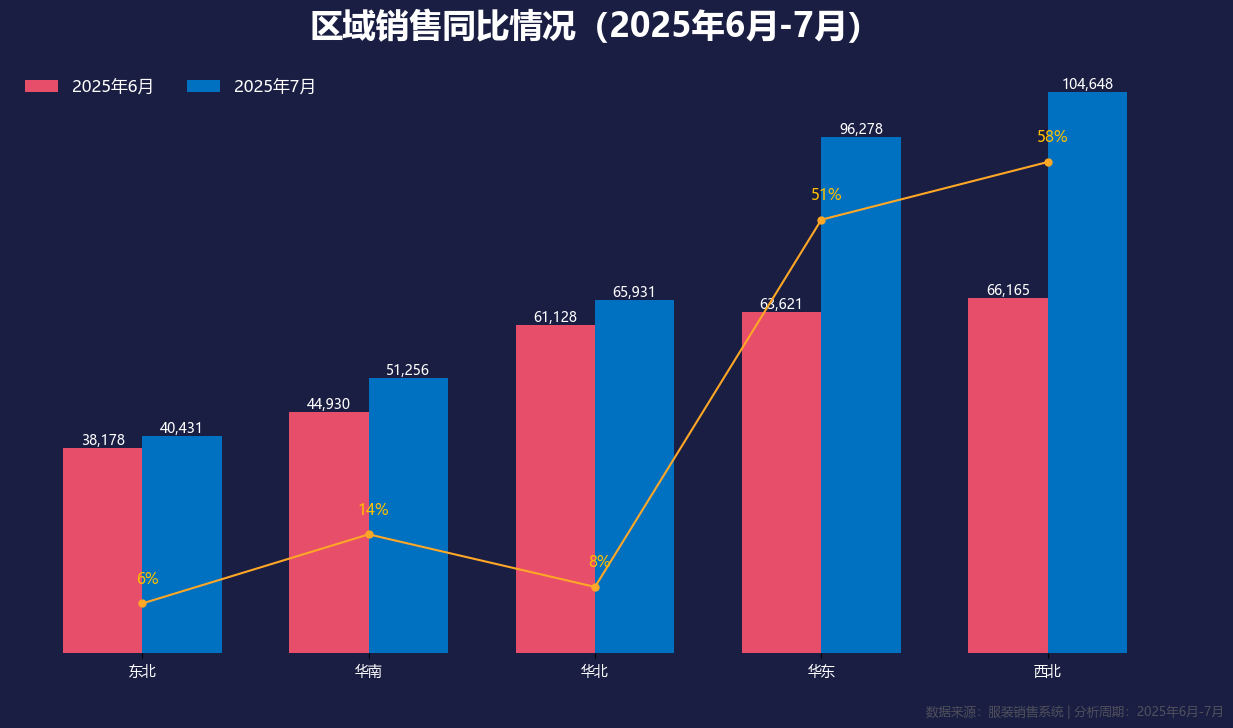

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

# 区域划分映射
REGION_MAP = {
    "华南": ["广东省", "广西壮族自治区", "海南省", "福建省"],
    "华北": ["北京市", "天津市", "河北省", "山西省", "内蒙古自治区"],
    "东北": ["辽宁省", "吉林省", "黑龙江省"],
    "西北": ["陕西省", "甘肃省", "青海省", "宁夏回族自治区", "新疆维吾尔自治区"],
    "华东": ["上海市", "江苏省", "浙江省", "安徽省", "山东省", "江西省"]
}

def get_region(province):
    for region, provinces in REGION_MAP.items():
        if province in provinces:
            return region
    return "其他"

try:
    # 严格读取CSV文件
    orders = pd.read_csv('../../数据生成/erp_order.csv', encoding='utf-8-sig')
    
    # 检查必要的列是否存在
    required_columns = ['下单时间', '省份', '商品金额']
    for col in required_columns:
        if col not in orders.columns:
            raise ValueError(f"订单数据中缺少必要列: {col}")
    
    # 转换日期列
    orders['下单时间'] = pd.to_datetime(orders['下单时间'], errors='coerce')
    
    # 过滤无效日期
    orders = orders[orders['下单时间'].notnull()]
    
    # 添加区域列
    orders['区域'] = orders['省份'].apply(get_region)
    
    # 过滤掉"其他"区域
    orders = orders[orders['区域'] != "其他"]
    
    # 提取年份和月份
    orders['年份'] = orders['下单时间'].dt.year
    orders['月份'] = orders['下单时间'].dt.month
    
    # 确保只有2025年6月和7月的数据
    orders = orders[(orders['年份'] == 2025) & (orders['月份'].isin([6, 7]))]
    
    if orders.empty:
        raise ValueError("没有2025年6月或7月的订单数据")
    
    # 创建月份标识列（2025年6月/2025年7月）
    orders['月份标识'] = orders.apply(
        lambda x: f"2025年{x['月份']}月", 
        axis=1
    )
    
    # 按区域和月份标识汇总销售数据
    region_sales = orders.groupby(['区域', '月份标识'])['商品金额'].sum().reset_index()
    
    # 转换为宽格式
    pivot_data = region_sales.pivot(index='区域', columns='月份标识', values='商品金额').reset_index()
    
    # 确保两个月份都有数据
    required_months = ['2025年6月', '2025年7月']
    for month in required_months:
        if month not in pivot_data.columns:
            pivot_data[month] = 0
    
    # 填充缺失值为0
    pivot_data = pivot_data.fillna(0)
    
    # 转换为数值类型
    pivot_data['2025年6月'] = pd.to_numeric(pivot_data['2025年6月'], errors='coerce').fillna(0)
    pivot_data['2025年7月'] = pd.to_numeric(pivot_data['2025年7月'], errors='coerce').fillna(0)
    
    # 按2025年7月销售排序
    pivot_data = pivot_data.sort_values(by='2025年7月', ascending=True)
    
    # 创建深色背景的图表
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    fig.patch.set_facecolor('#1A1E43')
    ax.set_facecolor('#1A1E43')
    
    # 设置X轴
    x = np.arange(len(pivot_data))
    
    # 获取销售数据并转换为纯Python列表
    sales_jul = pivot_data['2025年7月'].tolist()
    sales_jun = pivot_data['2025年6月'].tolist()
    regions = pivot_data['区域'].tolist()

    # 创建6月和7月数据的条形图
    width = 0.35
    bars_jun = ax.bar(x - width/2, sales_jun, width, label='2025年6月', color='#e74e69', edgecolor='none')
    bars_jul = ax.bar(x + width/2, sales_jul, width, label='2025年7月', color='#0070c0', edgecolor='none')
    
    # 设置X轴
    ax.set_xticks(x)
    ax.set_xticklabels(regions, color='white')
    ax.legend(loc='upper left', facecolor='#1A1E43', frameon=False, ncol=2, fontsize=12, labelcolor='white')
    
    # 移除Y轴的标签和刻度
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.set_ylabel('')
    
    # 计算和创建连接两个月份的数据线
    sales_change = [(j - n) / n * 100 if n != 0 else 0 for j, n in zip(sales_jul, sales_jun)]
    ax2 = ax.twinx()
    ax2.set_facecolor('#1A1E43')
    ax2.set_ylim(0, max(max(sales_change), 15) * 1.2)
    ax2.plot(x, sales_change, '-o', color='#FFA726', markersize=5, label='增长率')

    # 移除ax2的刻度和刻度标签
    ax2.set_yticklabels([])
    ax2.set_yticks([])
    
    # 数据标签
    for bar_jun, bar_jul, change in zip(bars_jun, bars_jul, sales_change):
        height_jun = bar_jun.get_height()
        height_jul = bar_jul.get_height()
        ax.text(bar_jun.get_x() + bar_jun.get_width() / 2., height_jun, f'{int(height_jun):,}',
                ha='center', va='bottom', fontsize=10, color='white')
        ax.text(bar_jul.get_x() + bar_jul.get_width() / 2., height_jul, f'{int(height_jul):,}',
                ha='center', va='bottom', fontsize=10, color='white')
        ax2.annotate(f'{change:.0f}%', xy=(bar_jul.get_x() + bar_jul.get_width() / 2, change),
                    textcoords="offset points", xytext=(-25, 15), ha='center', fontsize=11, color='#ffc000')
    
    # 添加顶部标题
    plt.title('区域销售同比情况（2025年6月-7月）', color='white', fontsize=24, weight='bold', pad=20)
    
    # 移除边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    for spine in ax2.spines.values():
        spine.set_visible(False)

    # 添加说明
    plt.figtext(0.9, -0.03, '数据来源：服装销售系统 | 分析周期：2025年6月-7月', ha='center', fontsize=9, color='#666666', alpha=0.7)
    
    # 保存高清图片
    plt.tight_layout()
    plt.savefig('区域销售同比情况（2025年6月-7月）.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    plt.show()
    
except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析

- **东北区域**：
  - 6月销售额：38,178元
  - 7月销售额：40,431元
  - 同比增长率：6%
  - 分析：东北区域销售额呈现小幅增长，增长率为6%，显示出该区域市场的稳定性。

- **华南区域**：
  - 6月销售额：44,930元
  - 7月销售额：51,256元
  - 同比增长率：14%
  - 分析：华南区域销售额增长显著，增长率为14%，表明该区域市场需求增加。

- **华北区域**：
  - 6月销售额：61,128元
  - 7月销售额：65,931元
  - 同比增长率：8%
  - 分析：华北区域销售额稳步增长，增长率为8%，显示出该区域市场的持续发展。

- **华东区域**：
  - 6月销售额：68,621元
  - 7月销售额：96,278元
  - 同比增长率：51%
  - 分析：华东区域销售额大幅增长，增长率为51%，反映出该区域市场的强劲增长动力。

- **西北区域**：
  - 6月销售额：66,165元
  - 7月销售额：104,648元
  - 同比增长率：58%
  - 分析：西北区域销售额显著增长，增长率为58%，表明该区域市场潜力巨大。


# 结论

从区域销售同比情况来看，西北和华东区域的销售额增长最为显著，分别增长了58%和51%，显示出这两个区域的市场潜力和增长动力。华南和华北区域也表现出良好的增长趋势，而东北区域的增长率相对较低，仅为6%。